# Tugas Praktikum 11: Analisis Survei Beban Tugas & Tingkat Stres Mahasiswa
Pemuatan data, pembersihan, visualisasi, dan pemodelan Logistic Regression pada dataset survei mahasiswa — sesuai materi Pertemuan 11: Keterbatasan Perceptron dan Pengantar Logistic Regression.

## Import Library

In [63]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Membaca Dataset

In [64]:
df_raw = pd.read_csv("Survei Beban Tugas & Tingkat Stres Mahasiswa.csv")
display(df_raw.head())

,Timestamp,Nama Lengkap,NIM,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress?,Stress
0,5/7/2026 10:37:10,Muhammad Rayhan Mumtaz,2024081040,5,5,7,Stress,1
1,5/7/2026 16:08:00,Elpam Jovi Anata,2025081046,2,1,10,Tidak Stress,0
2,5/7/2026 16:08:15,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,Tidak Stress,0
3,5/7/2026 16:08:37,Aura Keyfas Brilea,2025011015,4,2,6,Tidak Stress,0
4,5/7/2026 16:08:46,Nabila Dwi Novianti,2025011017,5,1,5,Stress,1


## 2. Data Cleaning
Langkah-langkah:
- Menghapus kolom tidak relevan (`Timestamp`, `Nama Lengkap`, `NIM`)
- Menghapus data duplikat
- Menangani missing values
- Mengubah label stress menjadi angka: `0` = Tidak Stress, `1` = Stress
- Memastikan format angka konsisten

In [65]:
df_clean = df_raw.copy()

# Menghapus kolom tidak relevan
kolom_hapus = ['Timestamp', 'Nama Lengkap', 'NIM']
kolom_hapus = [c for c in kolom_hapus if c in df_clean.columns]
df_clean.drop(columns=kolom_hapus, inplace=True)

# Menghapus duplikat
n_dup = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

# Menangani missing values
for col in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    else:
        mode_val = df_clean[col].mode()
        if not mode_val.empty:
            df_clean[col].fillna(mode_val[0], inplace=True)

# Mengubah label Stress? (teks) menjadi angka: 0 = Tidak Stress, 1 = Stress
df_clean['Stress'] = df_clean['Stress?'].map({'Stress': 1, 'Tidak Stress': 0})
df_clean.drop(columns=['Stress?'], inplace=True)

# Memastikan format angka konsisten
for col in ['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur', 'Stress']:
    df_clean[col] = df_clean[col].astype(int)

print(f"Duplikat dihapus   : {n_dup} baris")
print(f"Total baris bersih : {len(df_clean)}")
print(f"Sisa missing values: {df_clean.isnull().sum().sum()}")
print(f"Kolom tersisa      : {list(df_clean.columns)}")

display(df_clean.head())
display(df_clean.describe().round(2))

Duplikat dihapus   : 1 baris
Total baris bersih : 41
Sisa missing values: 0
Kolom tersisa      : ['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur', 'Stress']


,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress
0,5,5,7,1
1,2,1,10,0
2,1,0,4,0
3,4,2,6,0
4,5,1,5,1


,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress
count,41.00,41.00,41.00,41.00
mean,3.56,1.63,5.88,0.51
std,1.96,1.46,1.47,0.51
min,0.00,0.00,3.00,0.00
25%,2.00,1.00,5.00,0.00
50%,3.00,1.00,6.00,1.00
75%,5.00,2.00,7.00,1.00
max,10.00,6.00,10.00,1.00


### Visualisasi Data
Correlation matrix dan scatter plot untuk melihat hubungan antar fitur sebelum pemodelan.

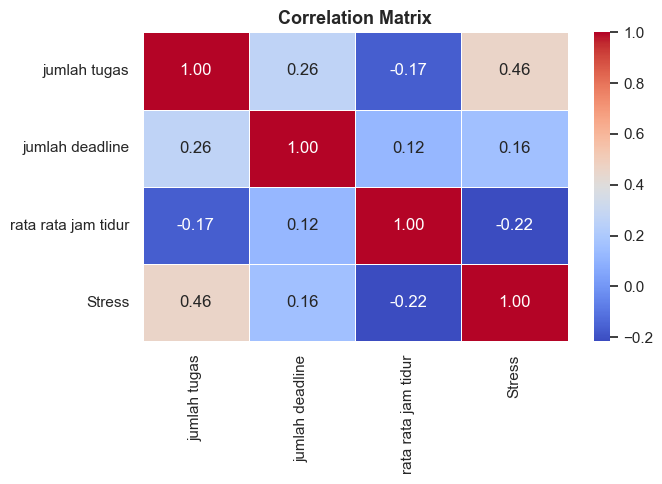

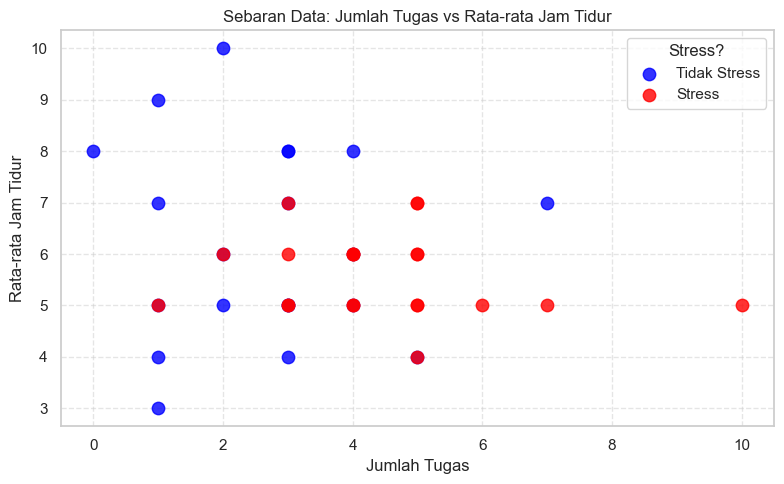

In [66]:
label_map = {0: 'Tidak Stress', 1: 'Stress'}
colors    = {0: 'blue', 1: 'red'}

# Correlation Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter Plot: Jumlah Tugas vs Rata-rata Jam Tidur
plt.figure(figsize=(8, 5))
for label, group in df_clean.groupby('Stress'):
    plt.scatter(group['jumlah tugas'], group['rata rata jam tidur'],
                label=label_map[label], color=colors[label], s=80, alpha=0.8)
plt.title('Sebaran Data: Jumlah Tugas vs Rata-rata Jam Tidur')
plt.xlabel('Jumlah Tugas')
plt.ylabel('Rata-rata Jam Tidur')
plt.legend(title='Stress?')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Feature Selection
Memilih fitur (variabel independen) dan target (variabel dependen) untuk model.

In [67]:
X = df_clean[['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur']]
y = df_clean['Stress']

print("Fitur (X):")
display(X.head())
print("\nTarget (y):")
print(y.value_counts().rename(index={0: 'Tidak Stress (0)', 1: 'Stress (1)'}).to_string())

Fitur (X):


,jumlah tugas,jumlah deadline,rata rata jam tidur
0,5,5,7
1,2,1,10
2,1,0,4
3,4,2,6
4,5,1,5



Target (y):
Stress
Stress (1)          21
Tidak Stress (0)    20


## 4. Split Data
Membagi dataset menjadi data training (80%) dan data testing (20%).

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total data   : {len(X)}")
print(f"Data training: {len(X_train)}")
print(f"Data testing : {len(X_test)}")

Total data   : 41
Data training: 32
Data testing : 9


## 5. Training Model
Melatih model Logistic Regression menggunakan data training.

In [69]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model berhasil dilatih!")
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': model.coef_[0]})
display(coef_df.sort_values('Koefisien', ascending=False).reset_index(drop=True))
print(f"Intercept: {model.intercept_[0]:.4f}")

Model berhasil dilatih!


,Fitur,Koefisien
0,jumlah tugas,0.484542
1,jumlah deadline,0.057655
2,rata rata jam tidur,-0.338994


Intercept: 0.2386


## 6. Prediction
Melakukan prediksi terhadap data testing.

In [70]:
y_pred = model.predict(X_test)

pred_df = X_test.copy()
pred_df['Label Sebenarnya'] = y_test.values
pred_df['Hasil Prediksi']   = y_pred
pred_df['Label Sebenarnya'] = pred_df['Label Sebenarnya'].map({0: 'Tidak Stress', 1: 'Stress'})
pred_df['Hasil Prediksi']   = pred_df['Hasil Prediksi'].map({0: 'Tidak Stress', 1: 'Stress'})
display(pred_df.reset_index(drop=True))

,jumlah tugas,jumlah deadline,rata rata jam tidur,Label Sebenarnya,Hasil Prediksi
0,5,2,4,Tidak Stress,Stress
1,0,0,8,Tidak Stress,Tidak Stress
2,5,2,6,Stress,Stress
3,5,2,4,Stress,Stress
4,5,1,6,Stress,Stress
5,5,5,7,Stress,Stress
6,1,1,5,Tidak Stress,Tidak Stress
7,5,1,5,Stress,Stress
8,3,1,7,Tidak Stress,Tidak Stress


## 7. Evaluation
Menampilkan akurasi, confusion matrix, dan classification report.

Accuracy: 88.89%

Classification Report:
              precision    recall  f1-score   support

Tidak Stress       1.00      0.75      0.86         4
      Stress       0.83      1.00      0.91         5

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



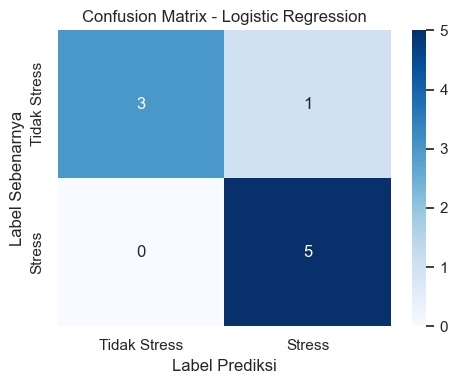

In [71]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Tidak Stress', 'Stress']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Stress', 'Stress'],
            yticklabels=['Tidak Stress', 'Stress'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

## 8. Probabilitas Prediksi
Menggunakan `predict_proba()` untuk menampilkan probabilitas hasil prediksi.
- Kolom pertama → probabilitas **Tidak Stress (0)**
- Kolom kedua → probabilitas **Stress (1)**

Contoh: `[0.22, 0.78]` artinya 22% kemungkinan tidak stress dan 78% kemungkinan stress.

In [72]:
y_proba = model.predict_proba(X_test)

proba_df = X_test.copy().reset_index(drop=True)
proba_df['P(Tidak Stress)'] = np.round(y_proba[:, 0], 2)
proba_df['P(Stress)']       = np.round(y_proba[:, 1], 2)
proba_df['Prediksi']        = pd.Series(y_pred).map({0: 'Tidak Stress', 1: 'Stress'})
display(proba_df)

,jumlah tugas,jumlah deadline,rata rata jam tidur,P(Tidak Stress),P(Stress),Prediksi
0,5,2,4,0.19,0.81,Stress
1,0,0,8,0.92,0.08,Tidak Stress
2,5,2,6,0.32,0.68,Stress
3,5,2,4,0.19,0.81,Stress
4,5,1,6,0.34,0.66,Stress
5,5,5,7,0.36,0.64,Stress
6,1,1,5,0.71,0.29,Tidak Stress
7,5,1,5,0.26,0.74,Stress
8,3,1,7,0.65,0.35,Tidak Stress
